## The purpose of this noetbook is to explore the overall UK crime and IMD data

I will include some visualisations which explore this further

In [20]:
!pip install geopandas

   ---------------------------------------- 0.0/22.9 MB ? eta -:--:--
   ---------------------------------------- 0.3/22.9 MB ? eta -:--:--
   - -------------------------------------- 1.0/22.9 MB 2.7 MB/s eta 0:00:09
   -- ------------------------------------- 1.6/22.9 MB 2.8 MB/s eta 0:00:08
   ---- ----------------------------------- 2.4/22.9 MB 3.1 MB/s eta 0:00:07
   ----- ---------------------------------- 3.4/22.9 MB 3.4 MB/s eta 0:00:06
   ------- -------------------------------- 4.5/22.9 MB 3.8 MB/s eta 0:00:05
   --------- ------------------------------ 5.5/22.9 MB 3.9 MB/s eta 0:00:05
   ---------- ----------------------------- 6.3/22.9 MB 4.0 MB/s eta 0:00:05
   ------------ --------------------------- 7.3/22.9 MB 4.1 MB/s eta 0:00:04
   ------------- -------------------------- 7.9/22.9 MB 4.0 MB/s eta 0:00:04
   ------------- -------------------------- 7.9/22.9 MB 4.0 MB/s eta 0:00:04
   --------------- ------------------------ 8.9/22.9 MB 3.8 MB/s eta 0:00:04
   ----------


[notice] A new release of pip is available: 25.2 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [ ]:
import pandas as pd
import numpy as np
import statistics 
import openpyxl
import seaborn as sns
import matplotlib.pyplot as plt


In [5]:
crime_df = pd.read_csv("CLEANED-regional_forces_crime_data_2024-2025.csv")
imd_df = pd.read_csv("clean_index_of_multiple_deprivation.csv")


# Check to see if there are corresponding columns
print(crime_df.columns) 
print(imd_df.columns)

# print(crime_df.info())

crime_df.rename(columns={"ITL1 region": "ITL1", "ITL2 region": "ITL2"}, inplace=True) # The two excel files have different names for the columns so I'm cleaning these to check
# print(imd_df["ITL1"].tail(4))
# print(crime_df["ITL1"].tail(4))

# crime_df.replace("East Midlands", "East Midlands (England)", inplace=True) # Making sure the data is uniform
# crime_df.replace("West Midlands","West Midlands (England)", inplace=True)

crime_df.loc[crime_df["ITL1"] == "East Midlands", "ITL1"] = "East Midlands (England)" # Making sure the data is uniform
crime_df.loc[crime_df["ITL1"] == "West Midlands", "ITL1"] = "West Midlands (England)"

Index(['Unnamed: 0', 'Financial Year', 'Financial Quarter', 'Force Name',
       'Offence Description', 'Offence Group', 'Offence Subgroup',
       'Offence Code', 'Number of Offences', 'ITL1 region', 'ITL2 region'],
      dtype='str')
Index(['IMD Rank', 'IMD Decile', 'ITL1', 'ITL2'], dtype='str')


In [6]:
data = crime_df.loc[:,"Number of Offences"]

def find_outliers_iqr(data):
    Q1 = np.percentile(data, 25)
    Q3 = np.percentile(data, 75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = data[(data < lower_bound) | (data >
    upper_bound)]
    return f"Here are the outliers: {outliers}, the lower bound: {lower_bound} and the upper bounds {upper_bound}."

find_outliers_iqr(data)






'Here are the outliers: 13       3607\n16       4819\n17        386\n33        571\n47        620\n         ... \n22387     603\n22401     277\n22408     425\n22420     726\n22446     982\nName: Number of Offences, Length: 3206, dtype: int64, the lower bound: -165.375 and the upper bounds 275.625.'

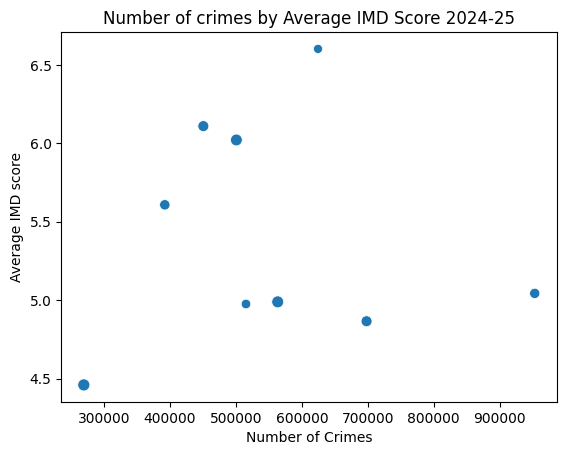

<Figure size 640x480 with 0 Axes>

In [7]:

ITL1_grouped_crimes = crime_df.groupby("ITL1")["Number of Offences"].sum()
# print(ITL1_grouped_crimes)
number_of_crimes = crime_df.groupby("Offence Group")["Number of Offences"].sum()

avg_imd_by_ITL1 = imd_df.groupby("ITL1")["IMD Decile"].mean() # Finding the average mean for the ITL1 regions IMD scores
avg_imd_by_ITL2 = imd_df.groupby("ITL2")["IMD Decile"].mean() # Finding the average mean for the ITL2 regions IMD scores
avg_imd_rank_by_ITL2 = imd_df.groupby("ITL2")["IMD Rank"].mean()
IMD2_dict = avg_imd_by_ITL2.to_dict()
IMD_dict = avg_imd_by_ITL1.to_dict()
IMD2_rank_dict = avg_imd_rank_by_ITL2.to_dict()
# print(ITL1_grouped_crimes)
# print(avg_imd_by_ITL1)

crime_df["IMD_ITL1"] = crime_df["ITL1"].map(IMD_dict)

regional_summary = crime_df.groupby("ITL1").agg(
    total_offences = ("Number of Offences", "sum"),
    avg_imd_by_ITL1 =("IMD_ITL1", "mean"))
#print(regional_summary)

regional_happiness = {"East (England)": 7.9, 
"East Midlands (England)": 7.5,
"London": 7.4,
"North East (England)": 8.7,
"North West (England)": 7.9,
"South East (England)": 6.6,
"South West (England)": 8.5,
"West Midlands (England)": 6.9,
"Yorkshire and The Humber": 8.6}

scores = [7.9, 7.5, 7.4, 8.7, 7.9, 6.6, 8.5,6.9,8.6 ]
data = np.array(scores)
squared_data = np.square(data)


happy_series = pd.Series(squared_data)


# regional_summary= happy_df.merge(regional_summary)


# new_df = ITL1_grouped_crimes.add(avg_imd_by_ITL1)
# print(new_df)
sns.scatterplot(x="total_offences", y="avg_imd_by_ITL1", s=happy_series, data=regional_summary)
plt.xlabel("Number of Crimes")
plt.ylabel("Average IMD score")
plt.title("Number of crimes by Average IMD Score 2024-25")
plt.show()

#To add:
# Labels per region / a colour legend
# Try and do the sizing by some kind of wellness metric
# DO some logarithms to make it more spaced out

plt.tight_layout()


This will create a function which finds the average IMD score per row

OR this will:
1) Explode the data so each row has a unique ITL2 region
2) With that information it will have the ITL2 average score & then I can group together based on the police force for the average IMD score (they will always be the same per category)
3) give a unique score per row

                                            total_offences  avg_imd_by_ITL2  \
ITL2                                                                          
Bedfordshire and Hertfordshire                      134350         6.610619   
Berkshire, Buckinghamshire and Oxfordshire          172209         7.286869   
Cambridgeshire and Peterborough                      67710         6.432171   

                                            avg_imd_rank_by_ITL2  
ITL2                                                              
Bedfordshire and Hertfordshire                      20739.552212  
Berkshire, Buckinghamshire and Oxfordshire          22988.432997  
Cambridgeshire and Peterborough                     20027.490310  


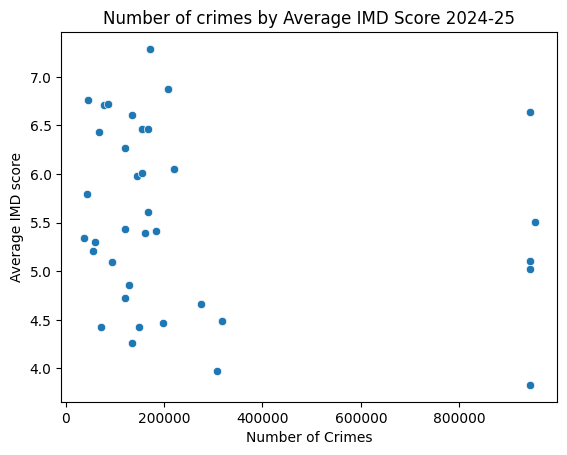

In [ ]:
# print(crime_df.info())
# print(crime_df["ITL2"])


# crime_df["ITL2"] = crime_df["ITL2"].apply(lambda x: x.split(";")) # This converts the values into a list so that I can find all of their IMD ratings
# print(crime_df["ITL2"])
individual_ITL2 = crime_df.explode("ITL2")
avg_imd_by_ITL2 = imd_df.groupby("ITL2")["IMD Decile"].mean()
IMD2_dict = avg_imd_by_ITL2.to_dict()
IMD2_rank_dict
individual_ITL2["IMD_ITL2"] = individual_ITL2["ITL2"].map(IMD2_dict)
individual_ITL2["IMD_rank_ITL2"] = individual_ITL2["ITL2"].map(IMD2_rank_dict)
# print(individual_ITL2.isnull().sum()) # Checking to see if this has gone back to 
# print(individual_ITL2.info())
# print(crime_df.info()) # Comparing the two datasets to make sure 1) It has exploded correctly, 2) They haven't combined together and 3) IT's all working
test = individual_ITL2.groupby("ITL2")["Number of Offences"].sum()


# individual_ITL2.to_csv("exploded_ITL2.csv")
# Now I will find the average IMD score per ITL2 region
regional_summary = individual_ITL2.groupby("ITL2").agg(
    total_offences = ("Number of Offences", "sum"),
    avg_imd_by_ITL2 =("IMD_ITL2", "mean"),
    avg_imd_rank_by_ITL2 = ("IMD_rank_ITL2", "mean")
    )
print(regional_summary.head(3)) # testing to see if it has created a good table
regional_summary.to_csv("machine_learning.csv")

sns.scatterplot(x="total_offences", y="avg_imd_by_ITL2",  data=regional_summary)
plt.xlabel("Number of Crimes")
plt.ylabel("Average IMD score")
plt.title("Number of crimes by Average IMD Score 2024-25")
plt.show()


Index(['Unnamed: 0', 'Financial Year', 'Financial Quarter', 'Force Name',
       'Offence Description', 'Offence Group', 'Offence Subgroup',
       'Offence Code', 'Number of Offences', 'ITL1', 'ITL2', 'IMD',
       'IMD ITL2'],
      dtype='str')
<class 'pandas.DataFrame'>
RangeIndex: 22464 entries, 0 to 22463
Data columns (total 13 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           22464 non-null  int64  
 1   Financial Year       22464 non-null  str    
 2   Financial Quarter    22464 non-null  int64  
 3   Force Name           22464 non-null  str    
 4   Offence Description  22464 non-null  str    
 5   Offence Group        22464 non-null  str    
 6   Offence Subgroup     22464 non-null  str    
 7   Offence Code         22464 non-null  str    
 8   Number of Offences   22464 non-null  int64  
 9   ITL1                 22464 non-null  str    
 10  ITL2                 22464 non-null  str    
 11 

Text(0.5, 1.0, 'Number of crimes by Average IMD Score 2024-25')

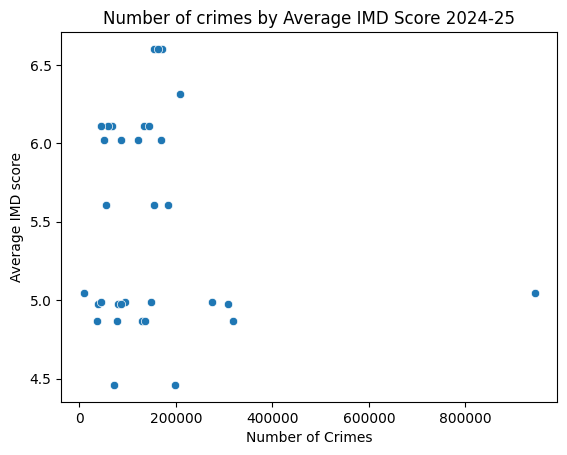

In [ ]:


ITL1_grouped_crimes = crime_df.groupby("ITL1")["Number of Offences"].sum()
number_of_crimes = crime_df.groupby("Offence Group")["Number of Offences"].sum()
# print(number_of_crimes)

avg_imd_by_ITL1 = imd_df.groupby("ITL1")["IMD Decile"].mean()
avg_imd_by_ITL2 = imd_df.groupby("ITL2")["IMD Decile"].mean()
IMD2_dict = avg_imd_by_ITL2.to_dict()
IMD_dict = avg_imd_by_ITL1.to_dict()
# print(IMD_dict)
print(crime_df.columns)
# Need to make a function that adds together the ITL2 regions IMD scores and finds the average among them

def find_avg_imd_score(crime_df, IMD2_dict):
    """
    This function allows me to explode the data, so I can map the regional score to the right ITL2 region and then will take an average of scores within that row.
    For example some Police Forces cover multiple ITL2 regions and therefore this is the most comprehensive, without going too broadly with the ITL1 regions
    """
    individual_ITL2 = crime_df[["Force Name","ITL2"]].explode("ITL2")
    ITL2_IMD_map = individual_ITL2.map(IMD2_dict)
    crime_df["IMD_avg"] = ITL2_IMD_map.groupby("Force Name")["IMD_score"].mean()
    return crime_df

crime_df["IMD ITL2"] = crime_df["ITL1"].map(IMD_dict)

crime_df.info()


regional_summary = crime_df.groupby("ITL2").agg(
    total_offences = ("Number of Offences", "sum"),
    avg_imd_by_ITL2 =("IMD ITL2", "mean"))




sns.scatterplot(x="total_offences", y="avg_imd_by_ITL2",  data=regional_summary)
plt.xlabel("Number of Crimes")
plt.ylabel("Average IMD score")
plt.title("Number of crimes by Average IMD Score 2024-25")

#TO do
# Try to see if there's any relationship between the two
